In [1]:
import numpy as np
import math
from scipy.constants import m_e, c, e, physical_constants
from scipy.special import gamma
import tqdm
import numba
import matplotlib.pyplot as plt

# Temperature from ionization

In [2]:
Uion = 13.6*e  # ionization energy in Joules, for Hydrogen

# Calculate the ADK prefactors (See Chen, JCP 236 (2013), equation (2))
# - Scalars
alpha = physical_constants['fine-structure constant'][0]
r_e = physical_constants['classical electron radius'][0]
wa = alpha**3 * c / r_e
Ea = m_e*c**2/e * alpha**4/r_e
# - Arrays (one element per ionization level)
UH = 13.6*e
Z = 1
n_eff = Z * np.sqrt( UH/Uion )
l_eff = n_eff - 1
C2 = 2**(2*n_eff) / (n_eff * gamma(n_eff+l_eff+1) * gamma(n_eff-l_eff))
# For now, we assume l=0, m=0
adk_power = - (2*n_eff - 1)
adk_prefactor = wa * C2 * ( Uion/(2*UH) ) \
    * ( 2*(Uion/UH)**(3./2)*Ea )**(2*n_eff - 1)
adk_exp_prefactor = -2./3 * ( Uion/UH )**(3./2) * Ea

In [9]:
@numba.njit
def get_fraction_and_temperature( a0, tau, lambd, ell, npts_per_wavelength=80 ):

    # Precompute a few things
    dt = lambd/c/npts_per_wavelength
    omega = 2*np.pi*c/lambd
    E0 = m_e*omega*c/e
    inv_tau2 = 1./tau**2
    # Check the ellipticity
    assert len(ell) == 2
    assert abs(ell[0]**2 + ell[1]**2 - 1) < 1.e-10 # Check that the ellipticity is normalized

    t = -3*tau # Start at 3 sigma
    ioniz_frac = 0
    kin_energy = 0

    while (t < 3*tau) and (ioniz_frac < 0.999):

        # Get the electric field and vector potential
        a_env = a0 * math.exp(-inv_tau2*t**2)
        a = a_env * math.sqrt( ell[0]**2*np.cos(omega*t)**2 + ell[1]**2*np.sin(omega*t)**2 )
        E = E0 * a_env * math.sqrt( ell[0]**2*np.sin(omega*t)**2 + ell[1]**2*np.cos(omega*t)**2 )                           

        # Get the ionization rate
        w = 0
        if E > 0:
            w = adk_prefactor * E**adk_power * math.exp( adk_exp_prefactor/E )
        dp = 1 - math.exp( -w*dt )

        # increment the ionization fraction
        kin_energy += (1 - ioniz_frac)*dp * m_e*c**2/e * (math.sqrt( 1 + a**2 ) - 1)
        ioniz_frac += (1 - ioniz_frac)*dp
        
        t += dt

    T = 0.
    if ioniz_frac > 0:
        T = kin_energy/(3/2*ioniz_frac)

    return ioniz_frac, T


In [10]:
a0 = 0.05
tau = 30e-15
lambd = 0.8e-6
ell = np.array([0,1]) 

get_fraction_and_temperature( a0, tau, lambd, ell )

(0.999015549502642, 2.8108202669874074)

Text(0, 0.5, 'Temperature (eV)')

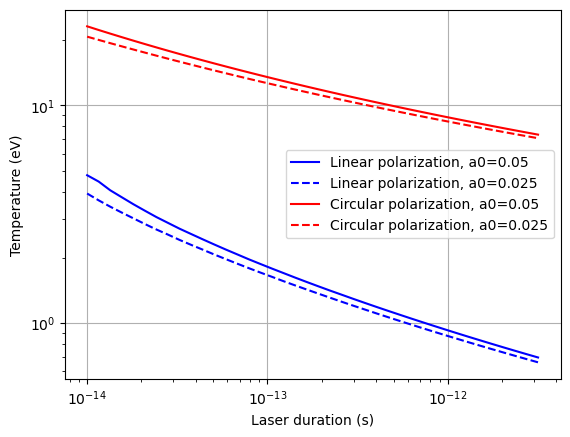

In [11]:
tau_arr = 10**np.linspace(-14, -11.5, 40)

a0 = 0.05
ell = np.array([0,1]) 
T_arr = [ get_fraction_and_temperature( a0, tau, lambd, ell )[1] for tau in tau_arr ]
plt.loglog( tau_arr, T_arr, 'b-', label='Linear polarization, a0=0.05' )

a0 = 0.025
ell = np.array([0,1]) 
T_arr = [ get_fraction_and_temperature( a0, tau, lambd, ell )[1] for tau in tau_arr ]
plt.loglog( tau_arr, T_arr, 'b--', label='Linear polarization, a0=0.025' )

a0 = 0.05
ell = np.array([1,1])/2**.5 
T_arr = [ get_fraction_and_temperature( a0, tau, lambd, ell )[1] for tau in tau_arr ]
plt.loglog( tau_arr, T_arr, 'r-', label='Circular polarization, a0=0.05' )

a0 = 0.025
ell = np.array([1,1])/2**.5 
T_arr = [ get_fraction_and_temperature( a0, tau, lambd, ell )[1] for tau in tau_arr ]
plt.loglog( tau_arr, T_arr, 'r--', label='Circular polarization, a0=0.025' )

plt.grid()
plt.legend(loc=0)

plt.xlabel('Laser duration (s)')
plt.ylabel('Temperature (eV)')

# Ionization volume for a focusing pulse

In [12]:
a0 = 0.05
w0 = 5.e-6
lambd = 0.8e-6
tau = 1.5e-12
ell = np.array([0,1]) 

zr = np.pi*w0**2/lambd

In [13]:
zmax = 400e-6
rmax = 50e-6
r, z = np.meshgrid( np.linspace(-rmax, rmax, 100), np.linspace(-zmax, zmax, 100), indexing='ij' )
a = a0/np.sqrt(1 + z**2/zr**2)*np.exp( -r**2/w0**2/(1+z**2/zr**2) )

n = np.zeros_like( a )
T = np.zeros_like( a )
for i in tqdm.tqdm( range(n.shape[0]) ):
    for j in range(n.shape[1]):
        ion, T0 = get_fraction_and_temperature( a[i,j], tau, lambd, ell )
        n[i,j] = ion
        T[i,j] = T0

100%|█████████████████████████████████████████| 100/100 [01:02<00:00,  1.61it/s]


Text(0, 0.5, 'r (microns)')

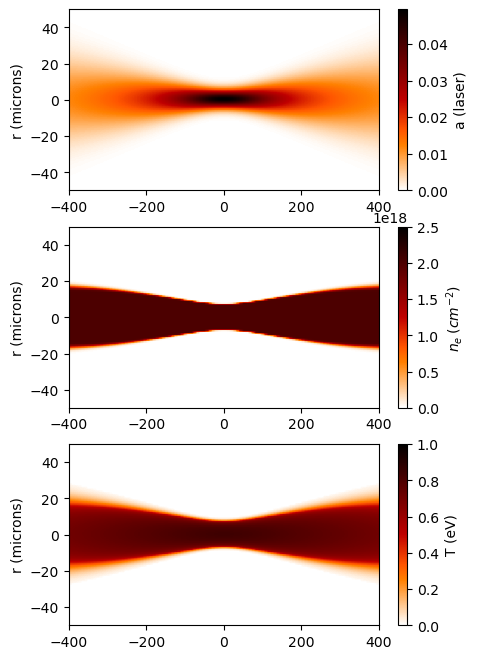

In [29]:
plt.figure(figsize=(5,8))

extent = 1.e6*np.array([-zmax, zmax, -rmax, rmax])

plt.subplot(311)
plt.imshow(a, extent=extent, aspect='auto', cmap='gist_heat_r')
cb = plt.colorbar()
cb.set_label('a (laser)')
plt.ylabel('r (microns)')

plt.subplot(312)
plt.imshow(2e18*n, extent=extent, aspect='auto', cmap='gist_heat_r', vmax=2.5e18)
cb = plt.colorbar()
cb.set_label('$n_e\;(cm^{-2})$')
plt.ylabel('r (microns)')

plt.subplot(313)
plt.imshow(T, extent=extent, aspect='auto', cmap='gist_heat_r', vmax=1)
cb = plt.colorbar()
cb.set_label('T (eV)')
plt.ylabel('r (microns)')

# Inverse Bremstrahlung

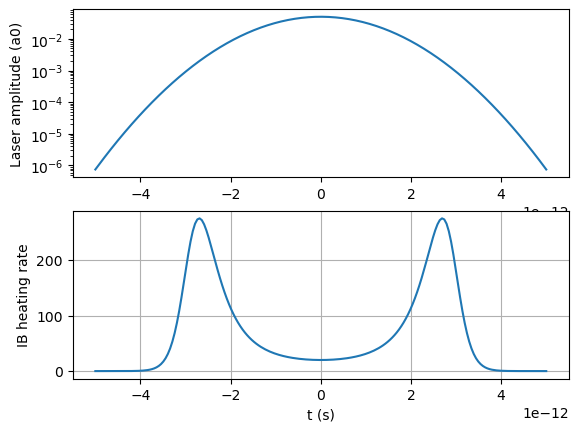

In [47]:
t_arr = np.linspace(-5e-12, 5e-12, 200)
a_arr = a0*np.exp(-t_arr**2/tau**2)

T_eV = 1
vth_over_c = np.sqrt( T_eV*e/(m_e*c**2) )
heating = a_arr**2/np.sqrt( vth_over_c**2 + a_arr**2 )**3

plt.subplot(211)
plt.semilogy( t_arr, a_arr )
plt.ylabel('Laser amplitude (a0)')

plt.subplot(212)
plt.plot( t_arr, heating )
plt.ylabel('IB heating rate')
plt.xlabel('t (s)')
plt.grid()